<a href="https://colab.research.google.com/github/adiban17/Deep-Learning-Models/blob/main/RNN_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Recurrent Neural Networks (RNNs)**

In this notebook I have implemented the following RNN Architectures:

1. Vanilla RNN
2. Deep/Stacked RNN
3. Bidirectional RNN
4. Stateful RNN

Install and Import

In [61]:
!pip install yfinance

In [62]:
# Importing necessary libraries

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Bidirectional
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam

Load Stock Market Data

In [63]:
# Load the last 5 years of Marsh Stock Data
df = yf.download("MRSH", period='5y', auto_adjust=True)[['Close']]
print(df.head(10))

[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker            MRSH
Date                  
2021-06-03  129.165863
2021-06-04  129.443893
2021-06-07  127.868355
2021-06-08  127.349365
2021-06-09  127.358620
2021-06-10  128.350327
2021-06-11  128.748825
2021-06-14  129.406845
2021-06-15  130.333618
2021-06-16  129.481018


In [64]:
df.shape

(1255, 1)

Preprocess the Data

In [65]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[0.04070695],
       [0.04312036],
       [0.02944405],
       ...,
       [0.30809933],
       [0.33049479],
       [0.32042549]])

In [66]:
# create dataset sequences

def create_sequences(data, window=30):
  '''
  This function is used to create sequences.
  We take a fixed sequence size let's say 30. Then the stock prices from 0-29th day will the independent variable 'X' (they will be stored as a sequence) and the output
  variable will be stored as 'y' which will be the stock price on the 30th day. In short, we use the prices from 0-29th day to preict the price for the 30th day. Note
  that the prices mentioned are the closing prices for the stock on that day.
  '''
  X, y = [], []
  for i in range(window, len(data)):
    X.append(data[i-window: i])
    y.append(data[i])
  return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_data, window=window_size)

In [67]:
X.shape

(1225, 30, 1)

In [68]:
y.shape

(1225, 1)

Create train, test splits

In [69]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [70]:
X_train.shape

(980, 30, 1)

In [71]:
X_test.shape

(245, 30, 1)

In [72]:
y_train.shape

(980, 1)

In [73]:
y_test.shape

(245, 1)

In [74]:
X[0]

array([[0.04070695],
       [0.04312036],
       [0.02944405],
       [0.02493901],
       [0.02501934],
       [0.03362776],
       [0.03708689],
       [0.04279877],
       [0.05084353],
       [0.04344262],
       [0.02035344],
       [0.        ],
       [0.01633126],
       [0.01938819],
       [0.02558299],
       [0.03089222],
       [0.04336209],
       [0.03732822],
       [0.05333761],
       [0.05124592],
       [0.06460044],
       [0.06435898],
       [0.06628974],
       [0.0664508 ],
       [0.05800405],
       [0.066692  ],
       [0.06049733],
       [0.0542224 ],
       [0.05349841],
       [0.0542224 ]])

In [75]:
y[0]

array([0.05647488])

In [76]:
X[30]

array([[0.05647488],
       [0.03805207],
       [0.05945135],
       [0.06500257],
       [0.09323971],
       [0.10538772],
       [0.10723808],
       [0.09975624],
       [0.08857368],
       [0.10480294],
       [0.10819413],
       [0.11441144],
       [0.13330539],
       [0.12167805],
       [0.13814957],
       [0.12975222],
       [0.13580848],
       [0.13322446],
       [0.1434784 ],
       [0.13936098],
       [0.14388238],
       [0.15914302],
       [0.1671364 ],
       [0.15437911],
       [0.16229195],
       [0.17206164],
       [0.17795618],
       [0.17319212],
       [0.1735961 ],
       [0.16875166]])

In [77]:
X[1]

array([[0.04312036],
       [0.02944405],
       [0.02493901],
       [0.02501934],
       [0.03362776],
       [0.03708689],
       [0.04279877],
       [0.05084353],
       [0.04344262],
       [0.02035344],
       [0.        ],
       [0.01633126],
       [0.01938819],
       [0.02558299],
       [0.03089222],
       [0.04336209],
       [0.03732822],
       [0.05333761],
       [0.05124592],
       [0.06460044],
       [0.06435898],
       [0.06628974],
       [0.0664508 ],
       [0.05800405],
       [0.066692  ],
       [0.06049733],
       [0.0542224 ],
       [0.05349841],
       [0.0542224 ],
       [0.05647488]])

In [78]:
y[1]

array([0.03805207])

In [79]:
X[31]

array([[0.03805207],
       [0.05945135],
       [0.06500257],
       [0.09323971],
       [0.10538772],
       [0.10723808],
       [0.09975624],
       [0.08857368],
       [0.10480294],
       [0.10819413],
       [0.11441144],
       [0.13330539],
       [0.12167805],
       [0.13814957],
       [0.12975222],
       [0.13580848],
       [0.13322446],
       [0.1434784 ],
       [0.13936098],
       [0.14388238],
       [0.15914302],
       [0.1671364 ],
       [0.15437911],
       [0.16229195],
       [0.17206164],
       [0.17795618],
       [0.17319212],
       [0.1735961 ],
       [0.16875166],
       [0.18191213]])

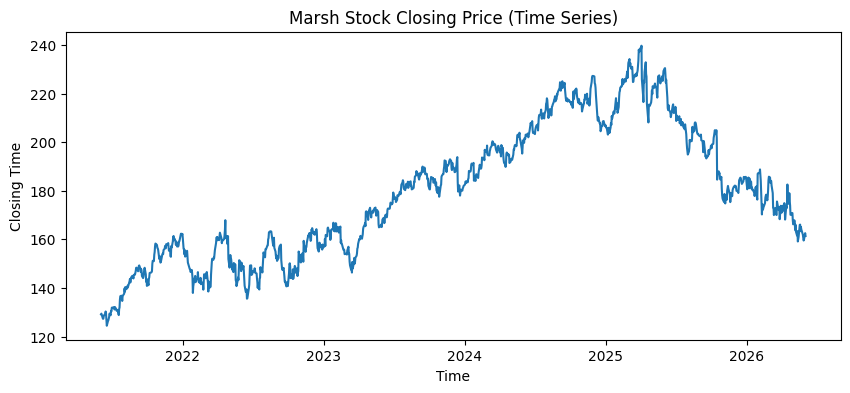

In [80]:
plt.figure(figsize=(10, 4))
plt.plot(df['Close'])
plt.title("Marsh Stock Closing Price (Time Series)")
plt.xlabel("Time")
plt.ylabel("Closing Time")
plt.show()

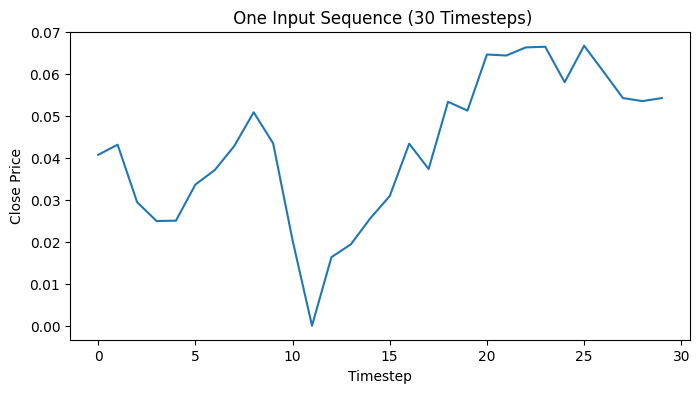

In [81]:
plt.figure(figsize=(8, 4))
plt.plot(X[0])
plt.title(" One Input Sequence (30 Timesteps)")
plt.xlabel("Timestep")
plt.ylabel("Close Price")
plt.show()

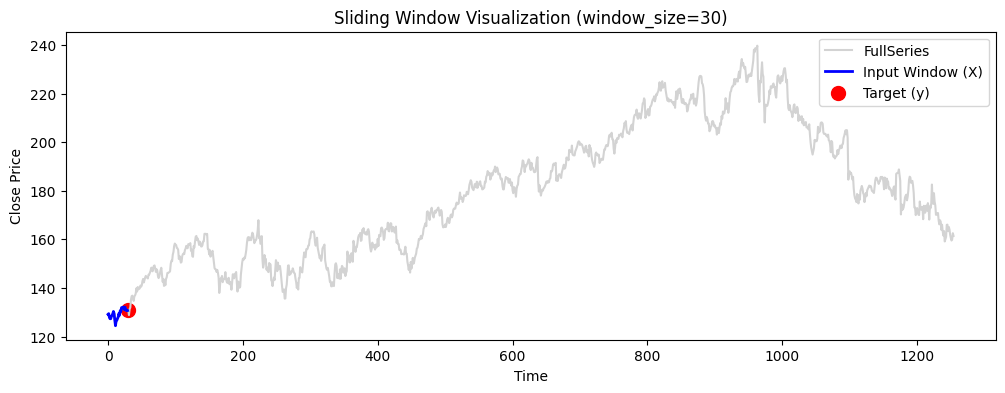

In [82]:
# Choose a sample index
i = 30

window_size = 30

plt.figure(figsize=(12, 4))

# Full Series
plt.plot(df['Close'].values, color='lightgray', label='FullSeries')

# Sliding Window (X)
plt.plot(range(i-window_size, i), df['Close'].values[i-window_size:i], color='blue', linewidth=2, label='Input Window (X)')

# Target Value (y)
plt.scatter(i, df['Close'].values[i], color='red', s=100, label="Target (y)")
plt.title("Sliding Window Visualization (window_size=30)")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

#### **VANILLA RNN**

In [83]:
model_rnn = Sequential([SimpleRNN(50, return_sequences=False, input_shape=(window_size, 1)), Dense(1)])

model_rnn.compile(optimizer="adam", loss="mse")
model_rnn.summary();

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_11 (SimpleRNN)       │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history_rnn = model_rnn.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0054 - val_loss: 0.0024
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.3674e-04 - val_loss: 9.8121e-04
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.0862e-04 - val_loss: 8.8403e-04
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.3084e-04 - val_loss: 8.8890e-04
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.9955e-04 - val_loss: 7.8529e-04
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.3430e-04 - val_loss: 7.5117e-04
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.3654e-04 - val_loss: 7.4017e-04
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.9508e-04 - val_loss: 7.7131e-04
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.2695e-04 - val_loss: 0.0010


Making Predictions

In [85]:
# Model Prediction
prediction = model_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)
for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}\nActual: {actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted: 220.52
Actual: 213.21
Predicted: 217.42
Actual: 215.28
Predicted: 216.77
Actual: 213.29
Predicted: 215.65
Actual: 212.56
Predicted: 215.12
Actual: 211.97
Predicted: 214.82
Actual: 210.29
Predicted: 213.37
Actual: 212.15
Predicted: 213.24
Actual: 214.99
Predicted: 214.02
Actual: 215.54
Predicted: 215.15
Actual: 212.24
Predicted: 215.91
Actual: 211.96
Predicted: 215.33
Actual: 212.89
Predicted: 214.14
Actual: 214.53
Predicted: 214.76
Actual: 213.74
Predicted: 215.79
Actual: 208.72
Predicted: 213.71
Actual: 211.04
Predicted: 213.41
Actual: 209.15
Predicted: 212.34
Actual: 209.16
Predicted: 211.73
Actual: 210.14
Predicted: 211.53
Actual: 210.67
Predicted: 212.43
Actual: 207.76
Predicted: 212.00
Actual: 209.56
Predicted: 211.48
Actual: 206.94
Predicted: 210.61
Actual: 208.00
Predicted: 210.28
Actual: 207.07
Predicted: 209.57
Actual: 208.29
Predicted: 209.84
Actual: 206.06
Predicted: 208.87
Actual: 206.35
Predicted: 209.05
Actual: 205.86
Predi

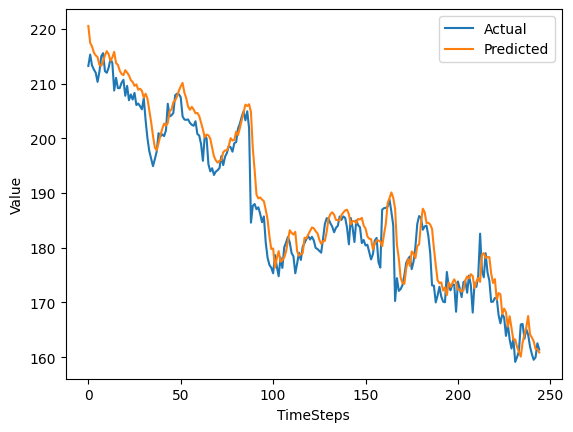

In [86]:
# Plotting the Actual v/s Predicted Values

plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("TimeSteps")
plt.ylabel("Value")
plt.legend()
plt.show()

#### **DEEP/STACKED RNN**

In [87]:
model_deep_rnn = Sequential([SimpleRNN(50, return_sequences=True, input_shape=(window_size, 1)), SimpleRNN(50), Dense(1)])
model_deep_rnn.compile(optimizer='adam', loss='mse')
model_deep_rnn.summary()

history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0464 - val_loss: 0.0022
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0032 - val_loss: 0.0026
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0015 - val_loss: 0.0017
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.0688e-04 - val_loss: 0.0011
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.5235e-04 - val_loss: 0.0011
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.5282e-04 - val_loss: 0.0011


In [88]:
# Model Prediction
prediction = model_deep_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)
for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}\nActual: {actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Predicted: 221.18
Actual: 213.21
Predicted: 216.55
Actual: 215.28
Predicted: 213.73
Actual: 213.29
Predicted: 214.87
Actual: 212.56
Predicted: 214.62
Actual: 211.97
Predicted: 214.59
Actual: 210.29
Predicted: 214.16
Actual: 212.15
Predicted: 213.78
Actual: 214.99
Predicted: 213.67
Actual: 215.54
Predicted: 214.67
Actual: 212.24
Predicted: 214.81
Actual: 211.96
Predicted: 214.01
Actual: 212.89
Predicted: 212.94
Actual: 214.53
Predicted: 213.36
Actual: 213.74
Predicted: 214.12
Actual: 208.72
Predicted: 213.17
Actual: 211.04
Predicted: 211.44
Actual: 209.15
Predicted: 210.60
Actual: 209.16
Predicted: 210.84
Actual: 210.14
Predicted: 210.54
Actual: 210.67
Predicted: 209.58
Actual: 207.76
Predicted: 210.28
Actual: 209.56
Predicted: 209.79
Actual: 206.94
Predicted: 209.77
Actual: 208.00
Predicted: 209.52
Actual: 207.07
Predicted: 208.36
Actual: 208.29
Predicted: 207.60
Actual: 206.06
Predicted: 208.46
Actual: 206.35
Predicted: 207.35
Actual: 205.86
Predi

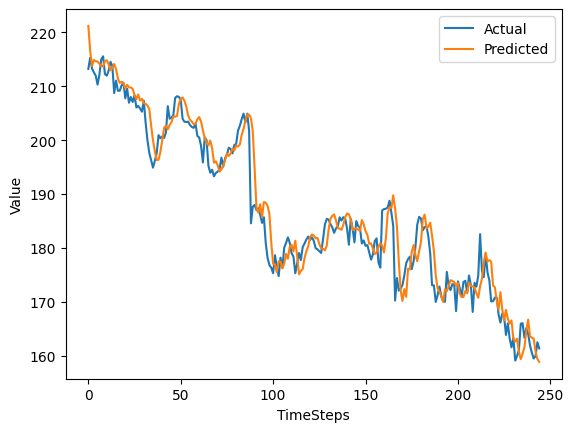

In [89]:
# Plotting the Actual v/s Predicted Values

plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("TimeSteps")
plt.ylabel("Value")
plt.legend()
plt.show()

#### **BiDirectional RNN**

In [90]:
model_birnn = Sequential([Bidirectional(SimpleRNN(50), input_shape=(window_size, 1)), Dense(1)])
model_birnn.compile(optimizer='adam', loss='mse')
model_birnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 100)            │         5,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
history_birnn = model_birnn.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=32)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0373 - val_loss: 0.0102
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016 - val_loss: 0.0034
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0010 - val_loss: 0.0019
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.2102e-04 - val_loss: 0.0028
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.9951e-04 - val_loss: 0.0023
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 8.5839e-04 - val_loss: 0.0018
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6572e-04 - val_loss: 0.0019


In [92]:
# Model Prediction
prediction = model_birnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)
for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}\nActual: {actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Predicted: 225.00
Actual: 213.21
Predicted: 224.72
Actual: 215.28
Predicted: 222.45
Actual: 213.29
Predicted: 219.04
Actual: 212.56
Predicted: 216.97
Actual: 211.97
Predicted: 216.36
Actual: 210.29
Predicted: 217.07
Actual: 212.15
Predicted: 216.71
Actual: 214.99
Predicted: 216.13
Actual: 215.54
Predicted: 215.52
Actual: 212.24
Predicted: 217.22
Actual: 211.96
Predicted: 217.46
Actual: 212.89
Predicted: 216.36
Actual: 214.53
Predicted: 214.62
Actual: 213.74
Predicted: 213.80
Actual: 208.72
Predicted: 214.08
Actual: 211.04
Predicted: 215.04
Actual: 209.15
Predicted: 214.88
Actual: 209.16
Predicted: 214.03
Actual: 210.14
Predicted: 215.45
Actual: 210.67
Predicted: 216.22
Actual: 207.76
Predicted: 215.76
Actual: 209.56
Predicted: 213.74
Actual: 206.94
Predicted: 211.09
Actual: 208.00
Predicted: 212.00
Actual: 207.07
Predicted: 212.90
Actual: 208.29
Predicted: 210.47
Actual: 206.06
Predicted: 207.53
Actual: 206.35
Predicted: 208.65
Actual: 205.86
Predi

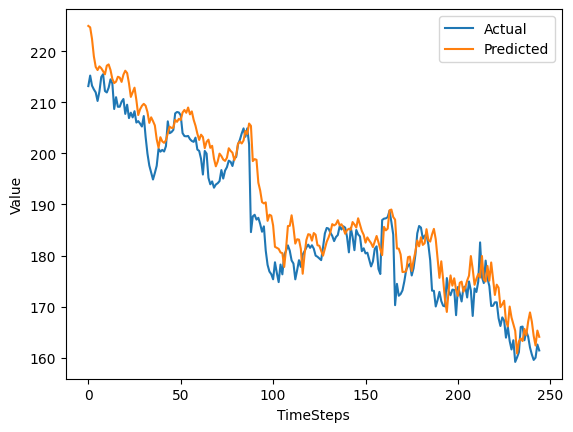

In [93]:
# Plotting the Actual v/s Predicted Values

plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("TimeSteps")
plt.ylabel("Value")
plt.legend()
plt.show()

#### **STATEFUL RNN**

In [94]:
batch = 32

model_stateful = Sequential([
    Input(batch_shape=(batch, window_size, 1)),
    SimpleRNN(50, stateful=True),
    Dense(1)
])
model_stateful.compile(optimizer='adam', loss='mse')
model_stateful.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_15 (SimpleRNN)       │ (32, 50)               │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
batch = 32

train_len = len(X_train) - (len(X_train) % batch)

X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]

print("Trimmed Training Shape:", X_train_s.shape)

Trimmed Training Shape: (960, 30, 1)


In [96]:
train_len

960

In [97]:
stateful_losses = []

for epoch in range(10):
  print(f"Epoch: {epoch+1}")

  history = model_stateful.fit(X_train_s, y_train_s, batch_size=batch, epochs=1, shuffle=False)

  # Store Less
  stateful_losses.append(history.history['loss'][0])

  # Reset RNN states after each epoch
  for layer in model_stateful.layers:
    if hasattr(layer, 'reset_states'):
      layer.reset_states()

Epoch: 1
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0075
Epoch: 2
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0121
Epoch: 3
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056
Epoch: 4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032
Epoch: 5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030
Epoch: 6
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024
Epoch: 7
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016
Epoch: 8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016
Epoch: 9
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0010
Epoch: 10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.2450e-04


#### Plot Loss Curves

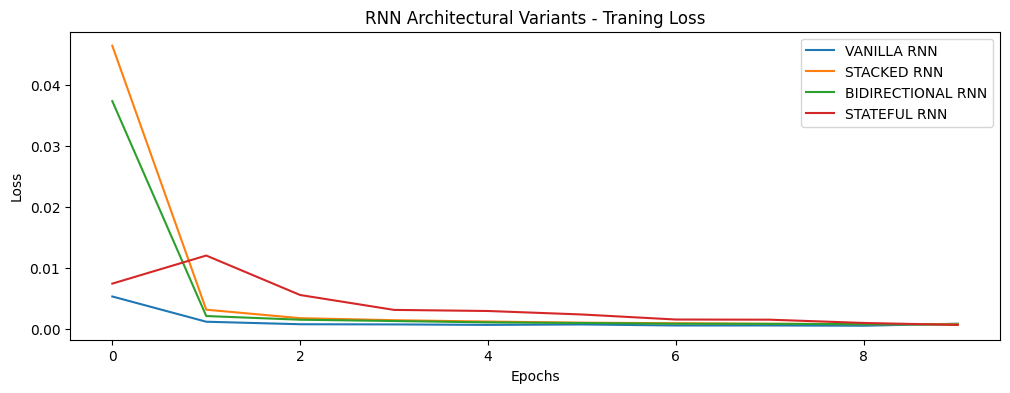

In [98]:
plt.figure(figsize=(12, 4))
plt.plot(history_rnn.history['loss'], label='VANILLA RNN')
plt.plot(history_deep_rnn.history['loss'], label='STACKED RNN')
plt.plot(history_birnn.history['loss'], label='BIDIRECTIONAL RNN')
plt.plot(stateful_losses, label='STATEFUL RNN')

plt.title("RNN Architectural Variants - Traning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()